In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shutil

project_dir = 'H:/My Drive/Penn/proj/sprg'

In [82]:
##
## Read in data
##

# need to scrape all 'Task2-SearchTask/AllPeptides.psmtsv' results from all species subdirectories. 
refseq_dir = os.path.join(project_dir, "data/refseq")
refseq_df = pd.DataFrame()
for subdir, dirs, files in os.walk(refseq_dir):
    for file in files:
        #print(os.path.join(subdir, file))
        if file.endswith("AllPeptides.psmtsv"):
            print(os.path.join(subdir, file))
            df = pd.read_table(os.path.join(subdir, file))
            #print(df.head())
            refseq_df = refseq_df.append(df)        
            
# merge an annotation file with the results file for prettier labeling
annotations_df = pd.read_csv(os.path.join(project_dir, "data/refseq/annotations.csv"))
refseq_df = pd.merge(refseq_df, annotations_df, on='File Name')
refseq_df.head()

H:/My Drive/Penn/proj/sprg\data/refseq\trout\Task2-SearchTask\AllPeptides.psmtsv


C:\Users\linds\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3444: DtypeWarning: Columns (15) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


H:/My Drive/Penn/proj/sprg\data/refseq\tomato\Task2-SearchTask\AllPeptides.psmtsv
H:/My Drive/Penn/proj/sprg\data/refseq\rice\Task2-SearchTask\AllPeptides.psmtsv


C:\Users\linds\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3444: DtypeWarning: Columns (20) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


H:/My Drive/Penn/proj/sprg\data/refseq\peach\Task2-SearchTask\AllPeptides.psmtsv
H:/My Drive/Penn/proj/sprg\data/refseq\human\Task2-SearchTask\AllPeptides.psmtsv
H:/My Drive/Penn/proj/sprg\data/refseq\cow\Task2-SearchTask\AllPeptides.psmtsv
H:/My Drive/Penn/proj/sprg\data/refseq\apple\Task2-SearchTask\AllPeptides.psmtsv


,File Name,Scan Number,Scan Retention Time,Num Experimental Peaks,Total Ion Current,Precursor Scan Number,Precursor Charge,Precursor MZ,Precursor Mass,Score,...,Improvement Possible,Cumulative Target,Cumulative Decoy,QValue,Cumulative Target Notch,Cumulative Decoy Notch,QValue Notch,PEP,PEP_QValue,Species
0,20211105_CAFishAQDDA_01-calib,40651,26.75427,200.0,4.394651e+06,40557,2.0,876.41406,1750.81356,31.364,...,,1,0,0.0,1,0,0.0,1.194477e-04,0.000047,Fish (lake trout)
1,20211105_CAFishAQDDA_01-calib,103571,72.30495,200.0,1.123507e+06,103498,2.0,996.98400,1991.95344,29.291,...,,2,0,0.0,2,0,0.0,1.180172e-05,0.000004,Fish (lake trout)
2,20211105_CAFishAQDDA_01-calib,70731,46.62882,200.0,5.035786e+06,70661,2.0,956.47513,1910.93571,28.334,...,,3,0,0.0,3,0,0.0,6.437302e-06,0.000002,Fish (lake trout)
3,20211105_CAFishAQDDA_01-calib,59482,38.89514,200.0,3.639337e+06,59437,2.0,871.93653,1741.85851,28.255,...,,4,0,0.0,4,0,0.0,1.890659e-04,0.000070,Fish (lake trout)
4,20211105_CAFishAQDDA_01-calib,70502,46.46306,200.0,8.191228e+07,70390,3.0,786.05844,2355.15349,27.396,...,,5,0,0.0,5,0,0.0,8.344650e-07,0.000000,Fish (lake trout)


In [83]:
list(refseq_df)

['File Name',
 'Scan Number',
 'Scan Retention Time',
 'Num Experimental Peaks',
 'Total Ion Current',
 'Precursor Scan Number',
 'Precursor Charge',
 'Precursor MZ',
 'Precursor Mass',
 'Score',
 'Delta Score',
 'Notch',
 'Base Sequence',
 'Full Sequence',
 'Essential Sequence',
 'Ambiguity Level',
 'PSM Count (unambiguous, <0.01 q-value)',
 'Mods',
 'Mods Chemical Formulas',
 'Mods Combined Chemical Formula',
 'Num Variable Mods',
 'Missed Cleavages',
 'Peptide Monoisotopic Mass',
 'Mass Diff (Da)',
 'Mass Diff (ppm)',
 'Protein Accession',
 'Protein Name',
 'Gene Name',
 'Organism Name',
 'Identified Sequence Variations',
 'Splice Sites',
 'Contaminant',
 'Decoy',
 'Peptide Description',
 'Start and End Residues In Protein',
 'Previous Amino Acid',
 'Next Amino Acid',
 'Theoreticals Searched',
 'Decoy/Contaminant/Target',
 'Matched Ion Series',
 'Matched Ion Mass-To-Charge Ratios',
 'Matched Ion Mass Diff (Da)',
 'Matched Ion Mass Diff (Ppm)',
 'Matched Ion Intensities',
 'Matched I

             Species   count
0              Apple   39047
1        Cow (liver)  205075
2  Fish (lake trout)   97869
3      Human (liver)  133872
4              Peach   44614


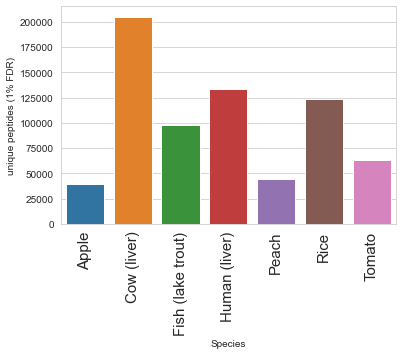

In [73]:
##
## Make a barplot of the detected peptides
##

peptide_df = refseq_df[['Species', 'Base Sequence']].drop_duplicates()
peptide_df = peptide_df.groupby(['Species']).agg(['count'])
peptide_df.columns = peptide_df.columns.droplevel(0)
peptide_df = peptide_df.reset_index()
print(peptide_df.head())

#colors = pd.DataFrame(
#    {'Species': ['Apple', 'Cow (liver)', 'Fish (lake trout)', 'Human (liver)', 'Peach', 'Rice', 'Tomato'],
#     'color': ['red', 'teal', 'blue', 'peru', 'peach', 'green', 'crimson']}
#)
colors = [['red', 'teal', 'blue', 'peru', 'peach', 'green', 'crimson']]

#peptide_df = pd.merge(peptide_df, colors, on='Species')

sns.set_style("whitegrid")
# Plot peptide detections per gradient length
g = sns.barplot(x='Species', y='count', data=peptide_df, capsize=.1, ci="sd")

#sns.swarmplot(x='Species', y='count', data=peptide_df, color="0", alpha=.5)
g.set_xticklabels(g.get_xticklabels(), fontsize=15, rotation='vertical')
g.set(xlabel='Species', ylabel='unique peptides (1% FDR)')
plt.show()

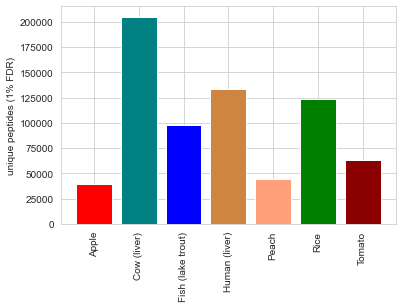

In [80]:
# Alternative barchart that gives specified colors

x_pos = np.arange(len(peptide_df['Species']))

# Create bars with different colors
plt.bar(x_pos, peptide_df['count'], 
        color=['red', 'teal', 'blue', 'peru', 'lightsalmon', 'green', 'darkred'])

# Create names on the x-axis
plt.xticks(x_pos, peptide_df['Species'], rotation = 90)
plt.ylabel('unique peptides (1% FDR)')

# Show graph
plt.show()

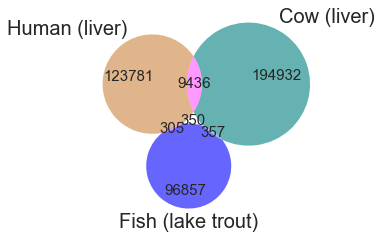

In [42]:
# Venn diagram for human/cow/fish overlaps
# upset plot?
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

plt.figure(edgecolor=None, facecolor=None)
c = venn3([set(refseq_df[refseq_df['Species'] == 'Human (liver)']['Base Sequence']), 
           set(refseq_df[refseq_df['Species'] == 'Cow (liver)']['Base Sequence']), 
           set(refseq_df[refseq_df['Species'] == 'Fish (lake trout)']['Base Sequence'])], 
          ('Human (liver)', 'Cow (liver)', 'Fish (lake trout)'))
c.get_patch_by_id('100').set_color('peru')  # set human color
c.get_patch_by_id('010').set_color('teal')  # set cow color
c.get_patch_by_id('001').set_color('blue')  # set fish color
c.get_patch_by_id('100').set_edgecolor('none')
c.get_patch_by_id('010').set_edgecolor('none')
c.get_patch_by_id('001').set_edgecolor('none')
c.get_patch_by_id('100').set_alpha(0.6)
c.get_patch_by_id('010').set_alpha(0.6)
c.get_patch_by_id('001').set_alpha(0.6)
c.get_patch_by_id('110').set_color('magenta')
c.get_patch_by_id('110').set_edgecolor('none')
c.get_patch_by_id('110').set_alpha(0.4)
#c.get_patch_by_id('101').set_color('cyan')
#c.get_patch_by_id('101').set_edgecolor('none')
#c.get_patch_by_id('101').set_alpha(0.4)
#c.get_patch_by_id('011').set_color('pink')
#c.get_patch_by_id('011').set_edgecolor('none')
#c.get_patch_by_id('011').set_alpha(0.4)
for text in c.set_labels:
    text.set_fontsize(20)
for text in c.subset_labels:
    text.set_fontsize(15)

matplotlib.pyplot.savefig('test.png')

             Species  count
0              Apple  27988
1        Cow (liver)  61437
2  Fish (lake trout)  51155
3      Human (liver)  61896
4              Peach  25724


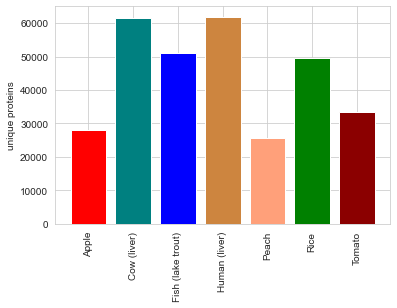

In [84]:
##
## Make a barplot of the detected proteins
## NOTE: this doesn't seem right, there's 60k proteins detected in human liver?? nahhh
## 

protein_df = refseq_df[['Species', 'Protein Accession']].drop_duplicates()
protein_df = protein_df.groupby(['Species']).agg(['count'])
protein_df.columns = protein_df.columns.droplevel(0)
protein_df = protein_df.reset_index()
print(protein_df.head())

x_pos = np.arange(len(peptide_df['Species']))

# Create bars with different colors
plt.bar(x_pos, protein_df['count'], 
        color=['red', 'teal', 'blue', 'peru', 'lightsalmon', 'green', 'darkred'])

# Create names on the x-axis
plt.xticks(x_pos, peptide_df['Species'], rotation = 90)
plt.ylabel('unique proteins')

# Show graph
plt.show()